# Modeling

In [58]:
import pandas as pd
import numpy as np
import geopandas as gpd
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import statsmodels.formula.api as smf
from statsmodels.stats.outliers_influence import variance_inflation_factor
from sklearn.model_selection import GroupKFold

## Data exploration

In [61]:
reviews10 = gpd.read_file("data/reviews_demog10.gpkg")
reviews20 = gpd.read_file("data/reviews_demog20.gpkg")

In [62]:
reviews10.columns

Index(['GentYN', 'TRACTCE10', 'GEO_ID', 'index_right', 'business_id', 'name',
       'address', 'city', 'state', 'postal_code_x', 'latitude', 'longitude',
       'stars', 'review_count', 'is_open', 'attributes', 'categories', 'hours',
       'LISTNAME', 'review_id', 'user_id', 'useful', 'funny', 'cool', 'text',
       'date', 'brewery', 'tot_pop', 'prop_black', 'prop_asian',
       'prop_hispanic_or_latino', 'prop_white_only', 'med_prop_val', 'med_inc',
       'total_25_plus', 'pct_bachelor_or_higher', 'pct_bachelor_lower',
       'geometry'],
      dtype='object')

In [63]:
reviews10.head()

,GentYN,TRACTCE10,GEO_ID,index_right,business_id,name,address,city,state,postal_code_x,...,prop_black,prop_asian,prop_hispanic_or_latino,prop_white_only,med_prop_val,med_inc,total_25_plus,pct_bachelor_or_higher,pct_bachelor_lower,geometry
0,0,000100,42101000100,125305.0,tZTIQ_8QzFZYrMn5u_M0Fg,Haru,241 Chestnut St,Philadelphia,PA,19106,...,0.06383,0.125359,0.036228,0.774583,354800.0,73041.0,2752.0,72.3,27.7,"MULTIPOLYGON (((2699719.191 236065.408, 269971..."
1,0,000100,42101000100,125309.0,tZTIQ_8QzFZYrMn5u_M0Fg,Haru,241 Chestnut St,Philadelphia,PA,19106,...,0.06383,0.125359,0.036228,0.774583,354800.0,73041.0,2752.0,72.3,27.7,"MULTIPOLYGON (((2699719.191 236065.408, 269971..."
2,0,000100,42101000100,125278.0,tZTIQ_8QzFZYrMn5u_M0Fg,Haru,241 Chestnut St,Philadelphia,PA,19106,...,0.06383,0.125359,0.036228,0.774583,354800.0,73041.0,2752.0,72.3,27.7,"MULTIPOLYGON (((2699719.191 236065.408, 269971..."
3,0,000100,42101000100,125276.0,tZTIQ_8QzFZYrMn5u_M0Fg,Haru,241 Chestnut St,Philadelphia,PA,19106,...,0.06383,0.125359,0.036228,0.774583,354800.0,73041.0,2752.0,72.3,27.7,"MULTIPOLYGON (((2699719.191 236065.408, 269971..."
4,0,000100,42101000100,125275.0,tZTIQ_8QzFZYrMn5u_M0Fg,Haru,241 Chestnut St,Philadelphia,PA,19106,...,0.06383,0.125359,0.036228,0.774583,354800.0,73041.0,2752.0,72.3,27.7,"MULTIPOLYGON (((2699719.191 236065.408, 269971..."


In [127]:
tract_agg10 = reviews10.groupby("GEO_ID").agg(
    sum_brew_reviews = ("brewery", "sum"),
    mean_brew_reviews = ("brewery", "mean"),
    prop_black = ("prop_black", "first"),
    prop_asian = ("prop_asian", "first"),
    prop_hispanic_or_latino = ("prop_hispanic_or_latino", "first"),
    med_prop_val = ("med_prop_val", "first"),
    med_inc = ("med_inc", "first"),
    pct_bachelor_or_higher = ("pct_bachelor_or_higher", "first"),
    gentrified = ("GentYN", "first"),
    geometry = ("geometry", "first")
)

tract_agg10 = gpd.GeoDataFrame(tract_agg10)
tract_agg10.head()



,sum_brew_reviews,mean_brew_reviews,prop_black,prop_asian,prop_hispanic_or_latino,med_prop_val,med_inc,pct_bachelor_or_higher,gentrified,geometry
GEO_ID,,,,,,,,,,
42101000100,101.0,0.039530,0.063830,0.125359,0.036228,354800.0,73041.0,72.3,0,"MULTIPOLYGON (((2699719.191 236065.408, 269971..."
42101000200,0.0,0.000000,0.102826,1.280899,0.026898,254700.0,43218.0,33.3,0,"MULTIPOLYGON (((2693797.182 238058.577, 269372..."
42101000300,21.0,0.106599,0.107920,0.244241,0.042600,456000.0,65577.0,68.8,0,"MULTIPOLYGON (((2689339.278 238715.088, 268909..."
42101000401,0.0,0.000000,0.186353,0.525176,0.050353,429600.0,21832.0,71.5,0,"MULTIPOLYGON (((2690854.957 236875.252, 269086..."
42101000402,0.0,0.000000,0.056652,0.243794,0.034691,152800.0,50020.0,58.9,0,"MULTIPOLYGON (((2693575.988 236479.419, 269360..."


In [128]:
tract_agg20 = reviews20.groupby("GEO_ID").agg(
    sum_brew_reviews = ("brewery", "sum"),
    mean_brew_reviews = ("brewery", "mean"),
    prop_black = ("prop_black", "first"),
    prop_asian = ("prop_asian", "first"),
    prop_hispanic_or_latino = ("prop_hispanic_or_latino", "first"),
    med_prop_val = ("med_prop_val", "first"),
    med_inc = ("med_inc", "first"),
    pct_bachelor_or_higher = ("pct_bachelor_or_higher", "first"),
    gentrified = ("GentYN", "first"),
    geometry = ("geometry", "first")
)

tract_agg20 = gpd.GeoDataFrame(tract_agg20)
tract_agg20.head()

,sum_brew_reviews,mean_brew_reviews,prop_black,prop_asian,prop_hispanic_or_latino,med_prop_val,med_inc,pct_bachelor_or_higher,gentrified,geometry
GEO_ID,,,,,,,,,,
42101000101,189.0,0.064704,0.054959,0.101331,0.055818,93462.0,104458.0,91.627635,0,"POLYGON ((2696727.529 235346.292, 2696698.358 ..."
42101000102,1.0,0.004049,0.050698,0.100826,0.059242,98400.0,104236.0,81.796783,0,"POLYGON ((2696854.461 237342.42, 2696826.709 2..."
42101000200,0.0,0.000000,0.084942,0.634096,0.037125,190300.0,83854.0,50.237530,0,"POLYGON ((2693678.98 237210.532, 2693630.886 2..."
42101000300,83.0,0.152015,0.080427,0.158631,0.061986,75611.0,84843.0,82.147743,0,"POLYGON ((2688851.053 238782.014, 2688858.091 ..."
42101000401,0.0,0.000000,0.089657,0.276977,0.053474,145592.0,73438.0,81.802351,0,"POLYGON ((2688653.351 236208.441, 2688775.578 ..."


In [129]:
print(tract_agg10.shape[0])
print(tract_agg20.shape[0])

384
408


In [130]:
print(tract_agg10.crs)
print(tract_agg20.crs)

None
None


In [131]:
tract_agg10 = tract_agg10.set_crs(reviews10.crs)
tract_agg20 = tract_agg20.set_crs(reviews20.crs)

(array([311.,  15.,   5.,   7.,   1.,   4.,   2.,   1.,   1.,   0.,   2.,
          0.,   1.,   0.,   0.,   0.,   0.,   0.,   0.,   2.]),
 array([0.  , 0.05, 0.1 , 0.15, 0.2 , 0.25, 0.3 , 0.35, 0.4 , 0.45, 0.5 ,
        0.55, 0.6 , 0.65, 0.7 , 0.75, 0.8 , 0.85, 0.9 , 0.95, 1.  ]),
 <BarContainer object of 20 artists>)

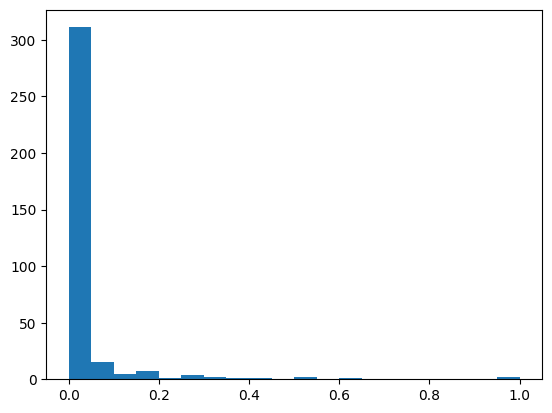

In [68]:
plt.hist(tract_agg20["mean_brew_reviews"], bins=20)

## Simple logistic regression models

In [15]:
mod_pre_1 = smf.logit("gentrified ~ mean_brew_reviews + prop_black+prop_asian+prop_hispanic_or_latino +med_prop_val + med_inc + pct_bachelor_or_higher",
                 data=tract_agg10).fit()

mod_pre_1.summary()

Optimization terminated successfully.
         Current function value: 0.357628
         Iterations 7


<class 'statsmodels.iolib.summary.Summary'>
"""
                           Logit Regression Results                           
==============================================================================
Dep. Variable:             gentrified   No. Observations:                  233
Model:                          Logit   Df Residuals:                      225
Method:                           MLE   Df Model:                            7
Date:                Sun, 24 May 2026   Pseudo R-squ.:                 0.08801
Time:                        21:09:15   Log-Likelihood:                -83.327
converged:                       True   LL-Null:                       -91.368
Covariance Type:            nonrobust   LLR p-value:                   0.02438
===========================================================================================
                              coef    std err          z      P>|z|      [0.025      0.975]
-------------------------------------------------------------------------------------------
Intercept                   0.7906      1.107      0.714      0.475      -1.379       2.961
mean_brew_reviews           4.2704      2.011      2.123      0.034       0.329       8.212
prop_black                 -1.3783      0.897     -1.536      0.124      -3.137       0.380
prop_asian                  0.9848      1.038      0.949      0.343      -1.050       3.019
prop_hispanic_or_latino    -1.8639      1.579     -1.181      0.238      -4.958       1.231
med_prop_val             -7.05e-06   4.37e-06     -1.615      0.106   -1.56e-05    1.51e-06
med_inc                 -3.976e-05   1.85e-05     -2.146      0.032   -7.61e-05   -3.45e-06
pct_bachelor_or_higher      0.0189      0.019      0.978      0.328      -0.019       0.057
===========================================================================================
"""

In [21]:
mod_post_1 = smf.logit("gentrified ~ mean_brew_reviews + prop_black+prop_asian+prop_hispanic_or_latino +med_prop_val + med_inc + pct_bachelor_or_higher",
                 data=tract_agg20).fit()

mod_post_1.summary()

Optimization terminated successfully.
         Current function value: 0.335132
         Iterations 7


<class 'statsmodels.iolib.summary.Summary'>
"""
                           Logit Regression Results                           
==============================================================================
Dep. Variable:             gentrified   No. Observations:                  328
Model:                          Logit   Df Residuals:                      320
Method:                           MLE   Df Model:                            7
Date:                Sun, 24 May 2026   Pseudo R-squ.:                 0.06540
Time:                        21:10:23   Log-Likelihood:                -109.92
converged:                       True   LL-Null:                       -117.61
Covariance Type:            nonrobust   LLR p-value:                   0.03139
===========================================================================================
                              coef    std err          z      P>|z|      [0.025      0.975]
-------------------------------------------------------------------------------------------
Intercept                  -2.9186      1.002     -2.911      0.004      -4.883      -0.954
mean_brew_reviews           1.8714      1.367      1.369      0.171      -0.808       4.551
prop_black                 -0.2373      0.924     -0.257      0.797      -2.049       1.574
prop_asian                  1.4267      2.244      0.636      0.525      -2.971       5.824
prop_hispanic_or_latino    -0.7435      1.873     -0.397      0.691      -4.414       2.927
med_prop_val            -3.234e-06   3.73e-06     -0.868      0.386   -1.05e-05    4.07e-06
med_inc                  6.591e-06   9.29e-06      0.710      0.478   -1.16e-05    2.48e-05
pct_bachelor_or_higher      0.0145      0.013      1.108      0.268      -0.011       0.040
===========================================================================================
"""

In [9]:
tract_agg10['sum_brew_reviews']

GEO_ID
42101000100    101.0
42101000200      0.0
42101000300     21.0
42101000401      0.0
42101000402      0.0
               ...  
42101980600      0.0
42101980700      0.0
42101980800      0.0
42101980900      0.0
42101989100      0.0
Name: sum_brew_reviews, Length: 384, dtype: float64

## Doing it by slope over time

In [132]:
reviews10['date'] = pd.to_datetime(reviews10['date'])
reviews10['month_enum'] = reviews10['date'].dt.year * 12 + reviews10['date'].dt.month

reviews20['date'] = pd.to_datetime(reviews20['date'])
reviews20['month_enum'] = reviews20['date'].dt.year * 12 + reviews20['date'].dt.month


# aggregate to census tract x month level
# get total reviews and brewery reviews per tract per month
tract_month10 = (reviews10.groupby(['GEO_ID', 'month_enum'])
              .agg(total_reviews=('brewery', 'count'),
                   brewery_reviews=('brewery', 'sum'))
              .reset_index())

tract_month20 = (reviews20.groupby(['GEO_ID', 'month_enum'])
              .agg(total_reviews=('brewery', 'count'),
                   brewery_reviews=('brewery', 'sum'))
              .reset_index())

# calculate proportion of brewery reviews
tract_month10['prop_brewery'] = tract_month10['brewery_reviews'] / tract_month10['total_reviews']
tract_month20['prop_brewery'] = tract_month20['brewery_reviews'] / tract_month20['total_reviews']

# OLS for each tract, extract slope (or 0 if less than 2 brewery reviews)
def get_slope(group):
    if group['brewery_reviews'].sum() == 0:
        return 0.0

    if len(group) < 2:
        return 0.0
    try:
        model = smf.ols('prop_brewery ~ month_enum', data=group).fit()
        return model.params['month_enum']
    except Exception:
        return 0.0

slopes10 = (tract_month10.groupby('GEO_ID')
          .apply(get_slope)
          .reset_index()
          .rename(columns={0: 'brewery_prop_slope'}))
slopes20 = (tract_month20.groupby('GEO_ID')
          .apply(get_slope)
          .reset_index()
          .rename(columns={0: 'brewery_prop_slope'}))


tract_agg10 = tract_agg10.merge(slopes10, on='GEO_ID', how='left')
tract_agg20 = tract_agg20.merge(slopes20, on='GEO_ID', how='left')

/var/folders/rz/h3gzrv2j09s6d_5vmn0bglw40000gn/T/ipykernel_41745/3344539311.py:38: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  .apply(get_slope)
/var/folders/rz/h3gzrv2j09s6d_5vmn0bglw40000gn/T/ipykernel_41745/3344539311.py:42: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  .apply(get_slope)


(array([  1.,   0.,   0.,   0.,   0.,   0.,   0.,   1.,   0.,   1.,   0.,
          0.,   0.,   0.,   0.,   1.,   1., 231.,   2.,   2.,   1.,   1.,
          1.,   1.,   0.,   0.,   1.,   0.,   0.,   1.]),
 array([-0.02394835, -0.02257442, -0.02120048, -0.01982655, -0.01845261,
        -0.01707867, -0.01570474, -0.0143308 , -0.01295686, -0.01158293,
        -0.01020899, -0.00883505, -0.00746112, -0.00608718, -0.00471325,
        -0.00333931, -0.00196537, -0.00059144,  0.0007825 ,  0.00215644,
         0.00353037,  0.00490431,  0.00627825,  0.00765218,  0.00902612,
         0.01040005,  0.01177399,  0.01314793,  0.01452186,  0.0158958 ,
         0.01726974]),
 <BarContainer object of 30 artists>)

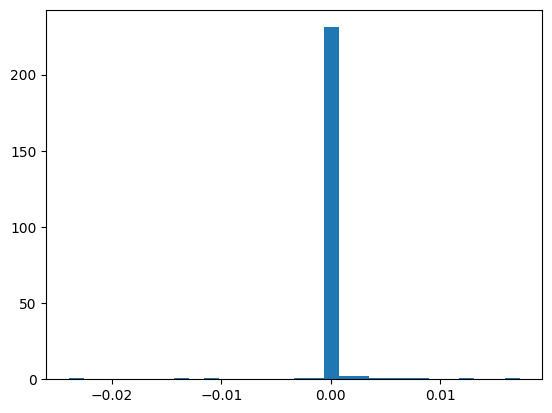

In [117]:
plt.hist(tract_agg10['brewery_prop_slope'], bins=30)

(array([  1.,   0.,   0.,   0.,   0.,   2.,   2.,   2.,   2.,   4., 308.,
          9.,  11.,   4.,   3.,   2.,   0.,   0.,   1.,   0.,   0.,   0.,
          0.,   0.,   0.,   0.,   0.,   0.,   0.,   1.]),
 array([-0.02001808, -0.01814881, -0.01627955, -0.01441028, -0.01254102,
        -0.01067175, -0.00880249, -0.00693322, -0.00506396, -0.00319469,
        -0.00132543,  0.00054384,  0.0024131 ,  0.00428237,  0.00615163,
         0.0080209 ,  0.00989016,  0.01175943,  0.01362869,  0.01549796,
         0.01736722,  0.01923649,  0.02110575,  0.02297502,  0.02484428,
         0.02671355,  0.02858281,  0.03045208,  0.03232134,  0.03419061,
         0.03605987]),
 <BarContainer object of 30 artists>)

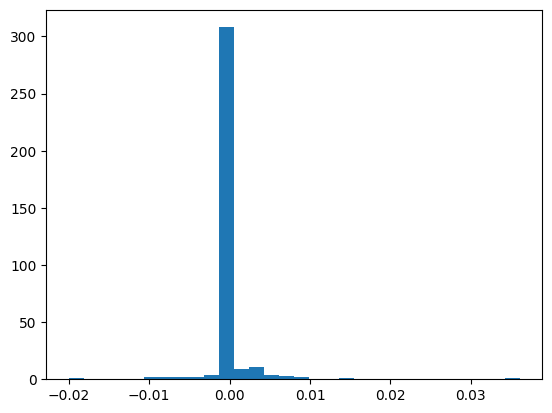

In [118]:
plt.hist(tract_agg20['brewery_prop_slope'], bins=30)

In [51]:
mod_pre_2 = smf.logit("gentrified ~  mean_brew_reviews + brewery_prop_slope + prop_black+prop_asian+prop_hispanic_or_latino +med_prop_val + med_inc + pct_bachelor_or_higher",
                 data=tract_agg10).fit()

mod_pre_2.summary()

Optimization terminated successfully.
         Current function value: 0.357317
         Iterations 7


<class 'statsmodels.iolib.summary.Summary'>
"""
                           Logit Regression Results                           
==============================================================================
Dep. Variable:             gentrified   No. Observations:                  233
Model:                          Logit   Df Residuals:                      224
Method:                           MLE   Df Model:                            8
Date:                Mon, 25 May 2026   Pseudo R-squ.:                 0.08880
Time:                        13:37:45   Log-Likelihood:                -83.255
converged:                       True   LL-Null:                       -91.368
Covariance Type:            nonrobust   LLR p-value:                   0.03925
===========================================================================================
                              coef    std err          z      P>|z|      [0.025      0.975]
-------------------------------------------------------------------------------------------
Intercept                   0.7983      1.108      0.720      0.471      -1.374       2.971
mean_brew_reviews           4.5483      2.185      2.082      0.037       0.266       8.830
brewery_prop_slope         23.3130     60.729      0.384      0.701     -95.714     142.340
prop_black                 -1.3878      0.899     -1.544      0.123      -3.149       0.374
prop_asian                  0.9602      1.043      0.921      0.357      -1.084       3.005
prop_hispanic_or_latino    -1.8739      1.581     -1.185      0.236      -4.973       1.226
med_prop_val            -7.013e-06   4.37e-06     -1.606      0.108   -1.56e-05    1.54e-06
med_inc                 -3.992e-05   1.85e-05     -2.158      0.031   -7.62e-05   -3.66e-06
pct_bachelor_or_higher      0.0186      0.019      0.967      0.334      -0.019       0.056
===========================================================================================
"""

In [56]:
X = mod_pre_2.model.exog
exog_names = mod_pre_2.model.exog_names

# Compute VIF for each feature (skip intercept at index 0)
vif_data = pd.DataFrame({
    'feature': exog_names[1:],
    'VIF': [variance_inflation_factor(X, i) for i in range(1, X.shape[1])]
})

print(vif_data.sort_values('VIF', ascending=False))

                   feature       VIF
5             med_prop_val  5.743094
7   pct_bachelor_or_higher  5.109614
6                  med_inc  2.348351
2               prop_black  1.961176
4  prop_hispanic_or_latino  1.453877
3               prop_asian  1.189151
0        mean_brew_reviews  1.085589
1       brewery_prop_slope  1.056106


In [52]:
mod_post_2 = smf.logit("gentrified ~  mean_brew_reviews + brewery_prop_slope + prop_black+prop_asian+prop_hispanic_or_latino +med_prop_val + med_inc + pct_bachelor_or_higher",
                 data=tract_agg20).fit()

mod_post_2.summary()

Optimization terminated successfully.
         Current function value: 0.334829
         Iterations 7


<class 'statsmodels.iolib.summary.Summary'>
"""
                           Logit Regression Results                           
==============================================================================
Dep. Variable:             gentrified   No. Observations:                  328
Model:                          Logit   Df Residuals:                      319
Method:                           MLE   Df Model:                            8
Date:                Mon, 25 May 2026   Pseudo R-squ.:                 0.06624
Time:                        13:37:48   Log-Likelihood:                -109.82
converged:                       True   LL-Null:                       -117.61
Covariance Type:            nonrobust   LLR p-value:                   0.04877
===========================================================================================
                              coef    std err          z      P>|z|      [0.025      0.975]
-------------------------------------------------------------------------------------------
Intercept                  -2.8801      1.006     -2.862      0.004      -4.853      -0.908
mean_brew_reviews           1.6623      1.462      1.137      0.256      -1.204       4.528
brewery_prop_slope         22.7113     50.035      0.454      0.650     -75.356     120.779
prop_black                 -0.2777      0.929     -0.299      0.765      -2.099       1.544
prop_asian                  1.3158      2.268      0.580      0.562      -3.129       5.761
prop_hispanic_or_latino    -0.7930      1.877     -0.422      0.673      -4.472       2.886
med_prop_val            -3.269e-06   3.75e-06     -0.871      0.384   -1.06e-05    4.09e-06
med_inc                    6.9e-06   9.33e-06      0.739      0.460   -1.14e-05    2.52e-05
pct_bachelor_or_higher      0.0138      0.013      1.044      0.296      -0.012       0.040
===========================================================================================
"""

In [54]:
X = mod_post_2.model.exog
exog_names = mod_post_2.model.exog_names

vif_data = pd.DataFrame({
    'feature': exog_names[1:],
    'VIF': [variance_inflation_factor(X, i) for i in range(1, X.shape[1])]
})

print(vif_data.sort_values('VIF', ascending=False))

                   feature       VIF
7   pct_bachelor_or_higher  4.193088
6                  med_inc  3.099726
2               prop_black  2.920698
4  prop_hispanic_or_latino  1.816978
5             med_prop_val  1.601182
3               prop_asian  1.478730
0        mean_brew_reviews  1.205934
1       brewery_prop_slope  1.130904


## GroupKFolds CV

In [ ]:
# spatial join with neighborhoods
neighborhoods = gpd.read_file("data/philadelphia-neighborhoods.gpkg")

neighborhoods.crs == tract_agg10.crs

False

In [133]:
neighborhoods = neighborhoods.to_crs(tract_agg10.crs)

In [119]:
neighborhoods.head()

,NAME,LISTNAME,MAPNAME,Shape_Leng,Shape_Area,geometry
0,BRIDESBURG,Bridesburg,Bridesburg,27814.546521,4.458626e+07,"MULTIPOLYGON (((2719790.253 256235.935, 271981..."
1,BUSTLETON,Bustleton,Bustleton,48868.458365,1.140504e+08,"MULTIPOLYGON (((2733378.53 289260.256, 2732819..."
2,CEDARBROOK,Cedarbrook,Cedarbrook,20021.415802,2.487174e+07,"MULTIPOLYGON (((2685268.357 279747.834, 268527..."
3,CHESTNUT_HILL,Chestnut Hill,Chestnut Hill,56394.297195,7.966498e+07,"MULTIPOLYGON (((2678490.547 284400.913, 267851..."
4,EAST_FALLS,East Falls,East Falls,27400.776417,4.057689e+07,"MULTIPOLYGON (((2686778.553 263597.711, 268692..."


In [136]:
tract_agg10

,GEO_ID,sum_brew_reviews,mean_brew_reviews,prop_black,prop_asian,prop_hispanic_or_latino,med_prop_val,med_inc,pct_bachelor_or_higher,gentrified,geometry,brewery_prop_slope
0,42101000100,101.0,0.039530,0.063830,0.125359,0.036228,354800.0,73041.0,72.3,0,"MULTIPOLYGON (((2699719.191 236065.408, 269971...",0.001183
1,42101000200,0.0,0.000000,0.102826,1.280899,0.026898,254700.0,43218.0,33.3,0,"MULTIPOLYGON (((2693797.182 238058.577, 269372...",0.000000
2,42101000300,21.0,0.106599,0.107920,0.244241,0.042600,456000.0,65577.0,68.8,0,"MULTIPOLYGON (((2689339.278 238715.088, 268909...",0.002529
3,42101000401,0.0,0.000000,0.186353,0.525176,0.050353,429600.0,21832.0,71.5,0,"MULTIPOLYGON (((2690854.957 236875.252, 269086...",0.000000
4,42101000402,0.0,0.000000,0.056652,0.243794,0.034691,152800.0,50020.0,58.9,0,"MULTIPOLYGON (((2693575.988 236479.419, 269360...",0.000000
...,...,...,...,...,...,...,...,...,...,...,...,...
379,42101980600,0.0,0.000000,NaN,NaN,NaN,NaN,NaN,NaN,0,"MULTIPOLYGON (((2691426.326 220141.048, 269139...",0.000000
380,42101980700,0.0,0.000000,0.600000,0.400000,0.200000,NaN,NaN,NaN,0,"MULTIPOLYGON (((2701739.982 227714.686, 269998...",0.000000
381,42101980800,0.0,NaN,0.333333,0.333333,0.000000,NaN,NaN,NaN,0,"MULTIPOLYGON (((2667372.271 244759.914, 266717...",NaN
382,42101980900,0.0,0.000000,0.633333,0.066667,0.066667,NaN,NaN,NaN,0,"MULTIPOLYGON (((2683004.87 230424.505, 2682862...",0.000000


In [137]:
# goal: join each census tract to the neighborhood in which *most* of its area lies in

def assign_tract_to_neighborhood(tracts, neighborhoods, neigh_name_col="LISTNAME", tract_id = "GEO_ID"):


    intersected = gpd.overlay(tracts, neighborhoods[[neigh_name_col, "geometry"]], how="intersection")
    intersected['intersection_area'] = intersected.geometry.area

    # find the neighborhood with the largest intersection area
    largest_intersect_idx = intersected.groupby(tract_id)["intersection_area"].idxmax()
    largest_intersect = intersected.loc[largest_intersect_idx, [tract_id, neigh_name_col]]

    tract_neigh = tracts.merge(largest_intersect[[tract_id, neigh_name_col]], how="left",on=tract_id)
    tract_neigh = tract_neigh.rename(columns={"LISTNAME":"neighborhood"})
    return tract_neigh

In [138]:
tract_neigh_10 = assign_tract_to_neighborhood(tract_agg10, neighborhoods)
tract_neigh_20 = assign_tract_to_neighborhood(tract_agg20, neighborhoods)

/Users/gabriellelow/anaconda3/envs/css/lib/python3.13/site-packages/geopandas/tools/overlay.py:358: UserWarning: `keep_geom_type=True` in overlay resulted in 19 dropped geometries of different geometry types than df1 has. Set `keep_geom_type=False` to retain all geometries
  result = _collection_extract(result, geom_type, keep_geom_type_warning)


In [139]:
tract_neigh_10.head()

,GEO_ID,sum_brew_reviews,mean_brew_reviews,prop_black,prop_asian,prop_hispanic_or_latino,med_prop_val,med_inc,pct_bachelor_or_higher,gentrified,geometry,brewery_prop_slope,neighborhood
0,42101000100,101.0,0.039530,0.063830,0.125359,0.036228,354800.0,73041.0,72.3,0,"MULTIPOLYGON (((2699719.191 236065.408, 269971...",0.001183,Old City
1,42101000200,0.0,0.000000,0.102826,1.280899,0.026898,254700.0,43218.0,33.3,0,"MULTIPOLYGON (((2693797.182 238058.577, 269372...",0.000000,Center City East
2,42101000300,21.0,0.106599,0.107920,0.244241,0.042600,456000.0,65577.0,68.8,0,"MULTIPOLYGON (((2689339.278 238715.088, 268909...",0.002529,Logan Square
3,42101000401,0.0,0.000000,0.186353,0.525176,0.050353,429600.0,21832.0,71.5,0,"MULTIPOLYGON (((2690854.957 236875.252, 269086...",0.000000,Logan Square
4,42101000402,0.0,0.000000,0.056652,0.243794,0.034691,152800.0,50020.0,58.9,0,"MULTIPOLYGON (((2693575.988 236479.419, 269360...",0.000000,Logan Square


### Pre-2010 reports

In [140]:

X = tract_neigh_10[['mean_brew_reviews', 'brewery_prop_slope', 'prop_black', 'prop_asian', 'prop_hispanic_or_latino', 'med_prop_val', 'med_inc', 'pct_bachelor_or_higher', 'neighborhood']]
y = tract_neigh_10['gentrified']

groups =X["neighborhood"]